MOUNT GOOGLE DRIVE

In [3]:
# Try to import Google Colab's Drive utility.
# If running locally, we will catch the ImportError and skip mounting.
try:
    from google.colab import drive
    # Mount Google Drive.
    drive.mount('/content/drive')
    IN_COLAB = True
    print("Mounted Google Drive successfully (running on Google Colab).")
except ImportError:
    IN_COLAB = False
    print("Running locally. Google Drive mount skipped.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


DEFINING PROJECT DIRECTORIES

In [5]:
# Import the os module for interacting with the operating system
# and managing file/folder paths.
import os

# Define the root directory of the project.
# If in Google Colab, use the Google Drive path.
# If running locally, resolve the path relative to the notebook's location.
if 'IN_COLAB' in globals() and IN_COLAB:
    PROJECT_DIR = "/content/drive/MyDrive/Colab Notebooks/Internship Work"
else:
    # Check if 'data' folder is in the current directory, or two levels up
    if os.path.exists("data"):
        PROJECT_DIR = os.getcwd()
    elif os.path.exists(os.path.join("..", "..", "data")):
        PROJECT_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
    else:
        # Default fallback to two levels up (the standard local project structure)
        PROJECT_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))

# Define the directory containing the original raw dataset.
RAW_DATA_DIR = os.path.join(PROJECT_DIR, "data", "raw")

# Define the directory where the cleaned dataset will be saved.
PROCESSED_DATA_DIR = os.path.join(PROJECT_DIR, "data", "processed")

# Define the directory where graphs and visualizations will be saved.
FIGURES_DIR = os.path.join(PROJECT_DIR, "outputs", "figures")

# Define the directory where summary tables will be saved.
TABLES_DIR = os.path.join(PROJECT_DIR, "outputs", "tables")

# Create all required directories if they do not already exist.
# exist_ok=True prevents errors if the folders already exist.
os.makedirs(RAW_DATA_DIR, exist_ok=True)
os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(TABLES_DIR, exist_ok=True)

# Display the directories to confirm that the project structure is correct.
print("Project directories created successfully.")
print(f"Project root:             {PROJECT_DIR}")
print(f"Raw data directory:       {RAW_DATA_DIR}")
print(f"Processed data directory: {PROCESSED_DATA_DIR}")
print(f"Figures directory:        {FIGURES_DIR}")
print(f"Tables directory:         {TABLES_DIR}")


Project directories created successfully.
Raw data directory:       /content/drive/MyDrive/Colab Notebooks/Internship Work/data/raw
Processed data directory: /content/drive/MyDrive/Colab Notebooks/Internship Work/data/processed
Figures directory:        /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/figures
Tables directory:         /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/tables


IMPORT REQUIRED LIBRARIES

In [6]:
# -------------------------
# Data manipulation
# -------------------------

# Pandas is used for working with tabular data.
import pandas as pd

# NumPy is used for numerical operations.
import numpy as np


# -------------------------
# Visualization
# -------------------------

# Matplotlib is the basic plotting library.
import matplotlib.pyplot as plt

# Seaborn provides high-level statistical visualizations.
import seaborn as sns


# -------------------------
# Statistical analysis
# -------------------------

# Statistical functions for outlier and distribution analysis.
from scipy import stats


# -------------------------
# Display configuration
# -------------------------

# Display all columns when printing DataFrames.
pd.set_option("display.max_columns", None)

# Display up to 100 rows when necessary.
pd.set_option("display.max_rows", 100)

# Set a clean default style for visualizations.
sns.set_theme(style="whitegrid")

# Set a consistent figure size for plots.
plt.rcParams["figure.figsize"] = (10, 6)

# Set the default resolution of saved figures.
plt.rcParams["figure.dpi"] = 100

print("All libraries imported successfully.")

All libraries imported successfully.


CREATE A REUSABLE GRAPH-SAVING FUNCTION

In [8]:
def save_figure(filename, dpi=300, bbox_inches="tight"):
    """
    Save the current Matplotlib figure to Google Drive.

    Parameters
    ----------
    filename : str
        Name of the output image file.
        Example: "target_distribution.png"

    dpi : int
        Image resolution.
        300 DPI is suitable for reports and presentations.

    bbox_inches : str
        "tight" removes unnecessary whitespace around the figure.
    """

    # Create the complete path where the figure will be saved.
    filepath = os.path.join(FIGURES_DIR, filename)

    # Save the current active figure.
    plt.savefig(
        filepath,
        dpi=dpi,
        bbox_inches=bbox_inches
    )

    # Print the location so we know where the file was saved.
    print(f"Figure saved successfully: {filepath}")

LOAD THE RAW DATASET

In [10]:
# Define the complete path to the raw CSV file.
RAW_DATA_PATH = os.path.join(
    RAW_DATA_DIR,
    "UCI_Credit_Card.csv"
)

# Load the CSV file into a Pandas DataFrame.
df_raw = pd.read_csv(RAW_DATA_PATH)

# Display the first five rows.
display(df_raw.head())

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [11]:
# Get the number of rows and columns.
num_rows, num_columns = df_raw.shape

print(f"Number of records: {num_rows:,}")
print(f"Number of columns: {num_columns}")

Number of records: 30,000
Number of columns: 25


DATASET STRUCTURE AND DATA TYPES

In [12]:
# Display information about:
# - column names
# - non-null values
# - data types
# - memory usage
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [14]:
print("First five rows:")
display(df_raw.head())

print("\nLast five rows:")
display(df_raw.tail())

First five rows:


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0



Last five rows:


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
29995,29996,220000.0,1,3,1,39,0,0,0,0,0,0,188948.0,192815.0,208365.0,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,29997,150000.0,1,3,2,43,-1,-1,-1,-1,0,0,1683.0,1828.0,3502.0,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,29998,30000.0,1,2,2,37,4,3,2,-1,0,0,3565.0,3356.0,2758.0,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,29999,80000.0,1,3,1,41,1,-1,0,0,0,-1,-1645.0,78379.0,76304.0,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1
29999,30000,50000.0,1,2,1,46,0,0,0,0,0,0,47929.0,48905.0,49764.0,36535.0,32428.0,15313.0,2078.0,1800.0,1430.0,1000.0,1000.0,1000.0,1


STANDARDIZE COLUMN NAMES

In [15]:
# Create a copy of the raw DataFrame.
# We do not modify df_raw directly so that the original data remains preserved.
df = df_raw.copy()

# Remove accidental whitespace from column names.
df.columns = df.columns.str.strip()

# Rename the target column to a shorter and clearer name.
df = df.rename(
    columns={
        "default.payment.next.month": "DEFAULT"
    }
)

# Display all column names after renaming.
print("Updated column names:")
print(df.columns.tolist())

Updated column names:
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'DEFAULT']


Removing ID Column

In [17]:
# Check whether the ID column exists.
if "ID" in df.columns:

    # Remove ID because it is only an identifier.
    # It does not represent a meaningful customer financial behaviour.
    df = df.drop(columns=["ID"])

    print("ID column removed successfully.")

else:

    # If ID does not exist, continue without making changes.
    print("ID column was not found. No removal was necessary.")

# Display the updated shape.
print(f"Current dataset shape: {df.shape}")

ID column was not found. No removal was necessary.
Current dataset shape: (30000, 24)


Check Missing Values

In [18]:
# Count the number of missing values in each column.
missing_counts = df.isnull().sum()

# Calculate the percentage of missing values in each column.
missing_percentages = (
    df.isnull().mean() * 100
).round(2)

# Create a summary table.
missing_summary = pd.DataFrame({
    "Missing Values": missing_counts,
    "Missing Percentage": missing_percentages
})

# Sort the table from highest to lowest number of missing values.
missing_summary = missing_summary.sort_values(
    by="Missing Values",
    ascending=False
)

# Display the missing value summary.
display(missing_summary)

,Missing Values,Missing Percentage
LIMIT_BAL,0,0.0
SEX,0,0.0
EDUCATION,0,0.0
MARRIAGE,0,0.0
AGE,0,0.0
PAY_0,0,0.0
PAY_2,0,0.0
PAY_3,0,0.0
PAY_4,0,0.0
PAY_5,0,0.0


DUPLICATE ROW ANALYSIS

In [21]:
# Count completely duplicated rows.
duplicate_count = df.duplicated().sum()

# Calculate the percentage of duplicate rows.
duplicate_percentage = (
    duplicate_count / len(df)
) * 100

print(f"Number of duplicate rows: {duplicate_count:,}")
print(f"Percentage of duplicate rows: {duplicate_percentage:.2f}%")

Number of duplicate rows: 35
Percentage of duplicate rows: 0.12%


In [22]:
# Remove exact duplicates only if they exist.
df = df.drop_duplicates().reset_index(drop=True)

In [24]:
# Count completely duplicated rows after deletion
duplicate_count = df.duplicated().sum()

# Calculate the percentage of duplicate rows.
duplicate_percentage = (
    duplicate_count / len(df)
) * 100

print(f"Number of duplicate rows: {duplicate_count:,}")
print(f"Percentage of duplicate rows: {duplicate_percentage:.2f}%")

Number of duplicate rows: 0
Percentage of duplicate rows: 0.00%


DATA TYPE VALIDATION

In [25]:
# Create a summary of all column data types.
dtype_summary = pd.DataFrame({
    "Feature": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Unique Values": [
        df[column].nunique()
        for column in df.columns
    ]
})

# Display the summary.
display(dtype_summary)

,Feature,Data Type,Unique Values
0,LIMIT_BAL,float64,81
1,SEX,int64,2
2,EDUCATION,int64,7
3,MARRIAGE,int64,4
4,AGE,int64,56
5,PAY_0,int64,11
6,PAY_2,int64,11
7,PAY_3,int64,11
8,PAY_4,int64,11
9,PAY_5,int64,10


TARGET VARIABLE VALIDATION (DEFAULT)

In [26]:
# Display the unique target values.
print("Unique values in DEFAULT:")
print(sorted(df["DEFAULT"].unique()))

# Check whether the target is binary.
if set(df["DEFAULT"].unique()).issubset({0, 1}):

    print("Target variable is correctly binary.")

else:

    print("Warning: Unexpected target values detected.")

Unique values in DEFAULT:
[np.int64(0), np.int64(1)]
Target variable is correctly binary.


TARGET DISTRIBUTION

In [27]:
# Count each target class.
target_counts = df["DEFAULT"].value_counts().sort_index()

# Calculate percentage distribution.
target_percentages = (
    df["DEFAULT"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

# Create a summary DataFrame.
target_summary = pd.DataFrame({
    "Class": target_counts.index,
    "Count": target_counts.values,
    "Percentage": target_percentages.round(2).values
})

# Replace numerical labels with readable descriptions.
target_summary["Class Name"] = target_summary["Class"].map({
    0: "Non-Default",
    1: "Default"
})

display(target_summary)

,Class,Count,Percentage,Class Name
0,0,23335,77.87,Non-Default
1,1,6630,22.13,Default


Target Distribution Graph

Figure saved successfully: /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/figures/01_target_distribution.png


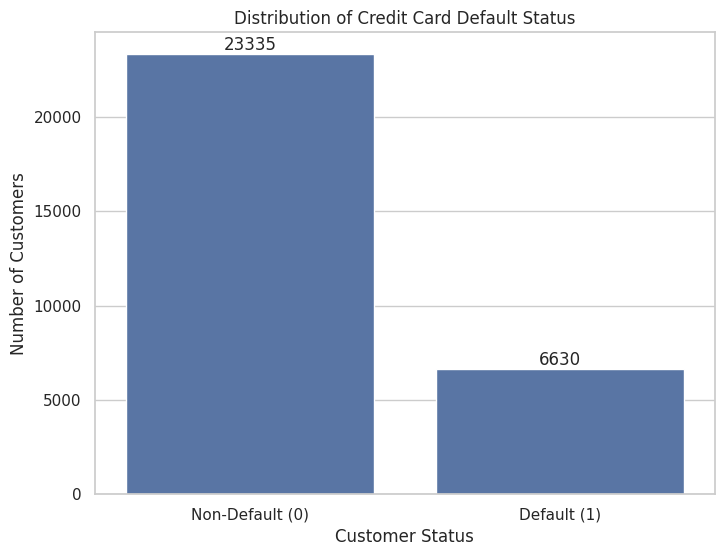

In [28]:
# Create a bar plot.
plt.figure(figsize=(8, 6))

ax = sns.countplot(
    data=df,
    x="DEFAULT"
)

# Add readable labels to the x-axis.
plt.xticks(
    ticks=[0, 1],
    labels=["Non-Default (0)", "Default (1)"]
)

# Add a title.
plt.title("Distribution of Credit Card Default Status")

# Add axis labels.
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

# Add count labels above each bar.
for container in ax.containers:

    ax.bar_label(container)

# Save the graph to Google Drive.
save_figure("01_target_distribution.png")

# Display the graph.
plt.show()

Feature Grouping

In [29]:
# Demographic features.
demographic_features = [
    "SEX",
    "EDUCATION",
    "MARRIAGE",
    "AGE"
]

# Credit-related features.
credit_features = [
    "LIMIT_BAL"
]

# Repayment status features.
repayment_features = [
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6"
]

# Monthly bill amount features.
bill_features = [
    "BILL_AMT1",
    "BILL_AMT2",
    "BILL_AMT3",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6"
]

# Monthly payment amount features.
payment_features = [
    "PAY_AMT1",
    "PAY_AMT2",
    "PAY_AMT3",
    "PAY_AMT4",
    "PAY_AMT5",
    "PAY_AMT6"
]

# Display the feature groups.
print("Demographic features:", demographic_features)
print("Credit features:", credit_features)
print("Repayment features:", repayment_features)
print("Bill features:", bill_features)
print("Payment features:", payment_features)

Demographic features: ['SEX', 'EDUCATION', 'MARRIAGE', 'AGE']
Credit features: ['LIMIT_BAL']
Repayment features: ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
Bill features: ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
Payment features: ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


Demographic Analysis

Figure saved successfully: /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/figures/03_age_distribution.png


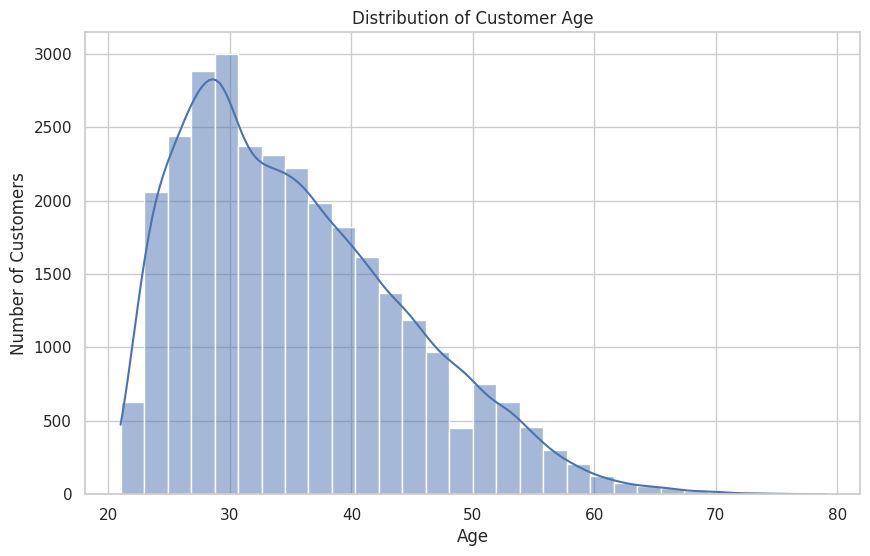

In [30]:
# ============================================================
# AGE DISTRIBUTION
# ============================================================

# Create a histogram of customer ages.
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="AGE",
    bins=30,
    kde=True
)

# Add title and labels.
plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

# Save the graph.
save_figure("03_age_distribution.png")

# Display the graph.
plt.show()

Figure saved successfully: /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/figures/04_age_by_default_status.png


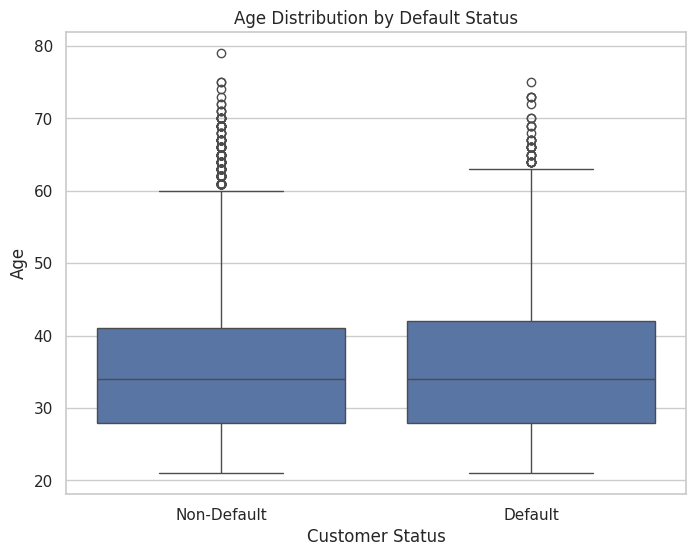

In [31]:
# ============================================================
# AGE DISTRIBUTION BY DEFAULT STATUS
# ============================================================

# Create boxplots comparing age distributions.
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="DEFAULT",
    y="AGE"
)

# Make labels readable.
plt.xticks(
    ticks=[0, 1],
    labels=["Non-Default", "Default"]
)

# Add title.
plt.title("Age Distribution by Default Status")

# Add labels.
plt.xlabel("Customer Status")
plt.ylabel("Age")

# Save the graph.
save_figure("04_age_by_default_status.png")

# Display the graph.
plt.show()

Figure saved successfully: /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/figures/sex_distribution_by_default.png


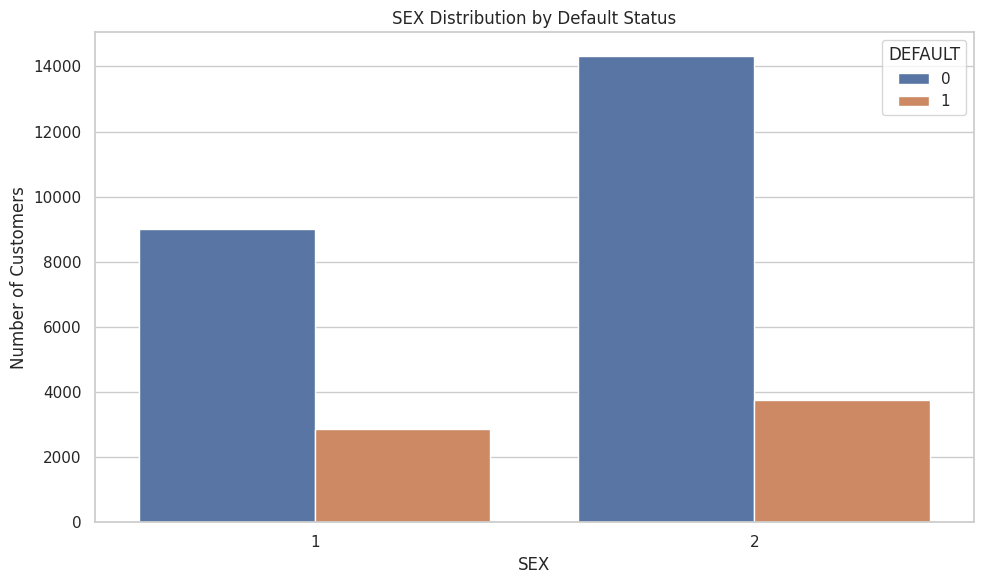

Figure saved successfully: /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/figures/education_distribution_by_default.png


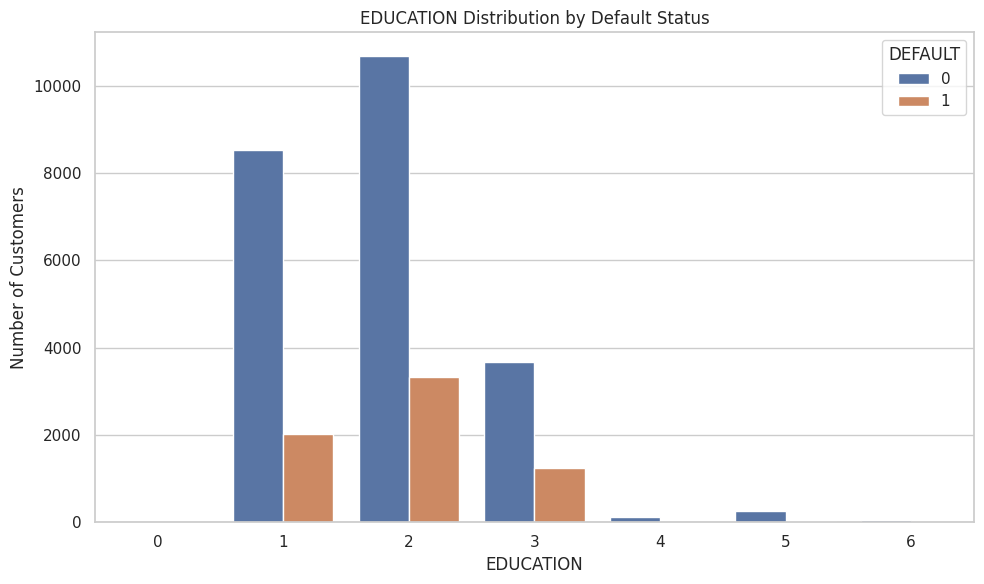

Figure saved successfully: /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/figures/marriage_distribution_by_default.png


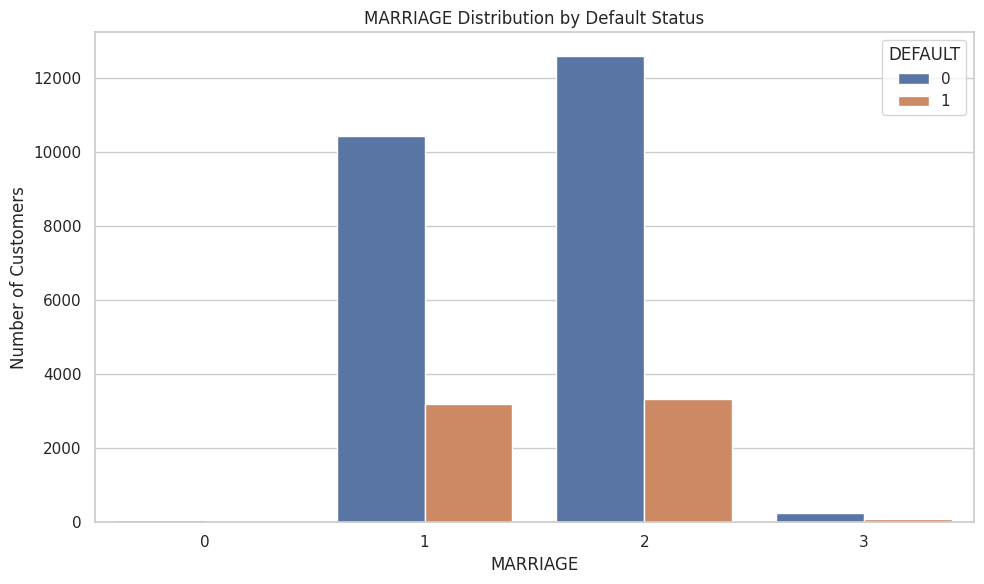

In [32]:
# ============================================================
# DEMOGRAPHIC FEATURE DISTRIBUTIONS
# ============================================================

# Create a list of categorical demographic features.
categorical_features = [
    "SEX",
    "EDUCATION",
    "MARRIAGE"
]

# Create one separate graph for each feature.
for feature in categorical_features:

    # Create a figure.
    plt.figure(figsize=(10, 6))

    # Create a count plot separated by default status.
    sns.countplot(
        data=df,
        x=feature,
        hue="DEFAULT"
    )

    # Add a descriptive title.
    plt.title(
        f"{feature} Distribution by Default Status"
    )

    # Add labels.
    plt.xlabel(feature)
    plt.ylabel("Number of Customers")

    # Adjust the layout.
    plt.tight_layout()

    # Save the graph.
    save_figure(
        f"{feature.lower()}_distribution_by_default.png"
    )

    # Display the graph.
    plt.show()

Figure saved successfully: /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/figures/08_credit_limit_distribution.png


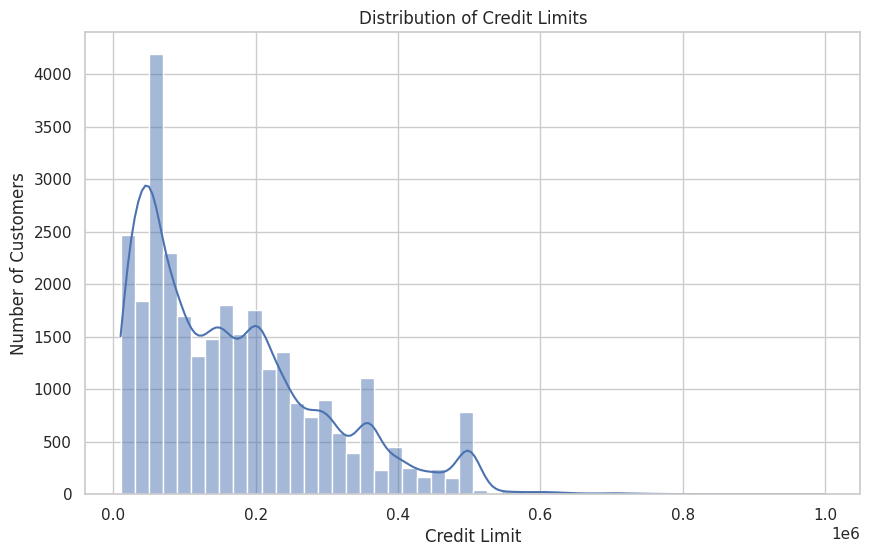

In [33]:
# ============================================================
#  CREDIT LIMIT DISTRIBUTION
# ============================================================

# Plot the distribution of assigned credit limits.
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="LIMIT_BAL",
    bins=50,
    kde=True
)

# Add title.
plt.title("Distribution of Credit Limits")

# Add labels.
plt.xlabel("Credit Limit")
plt.ylabel("Number of Customers")

# Save the graph.
save_figure("08_credit_limit_distribution.png")

# Display the graph.
plt.show()

Figure saved successfully: /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/figures/pay_0_by_default.png


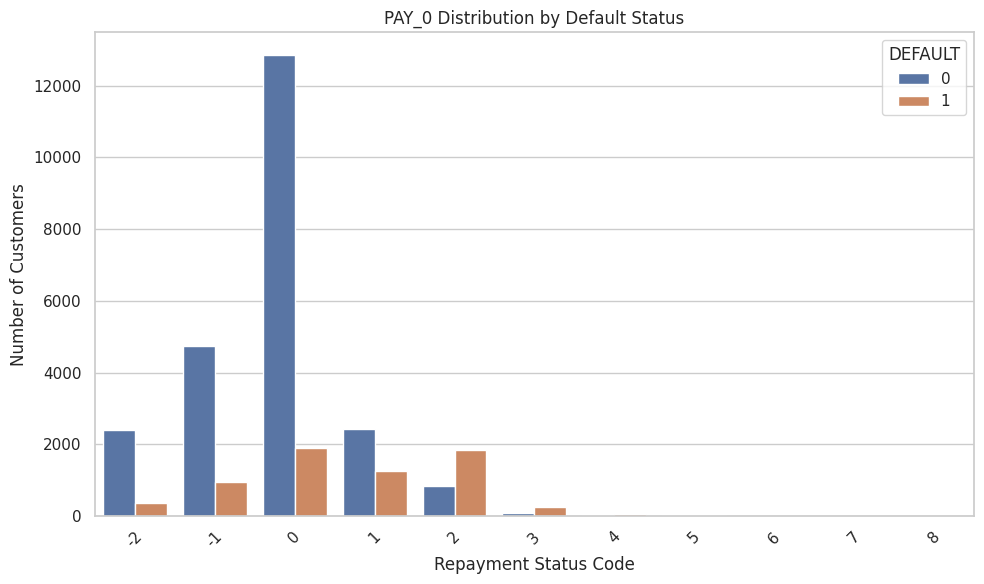

Figure saved successfully: /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/figures/pay_2_by_default.png


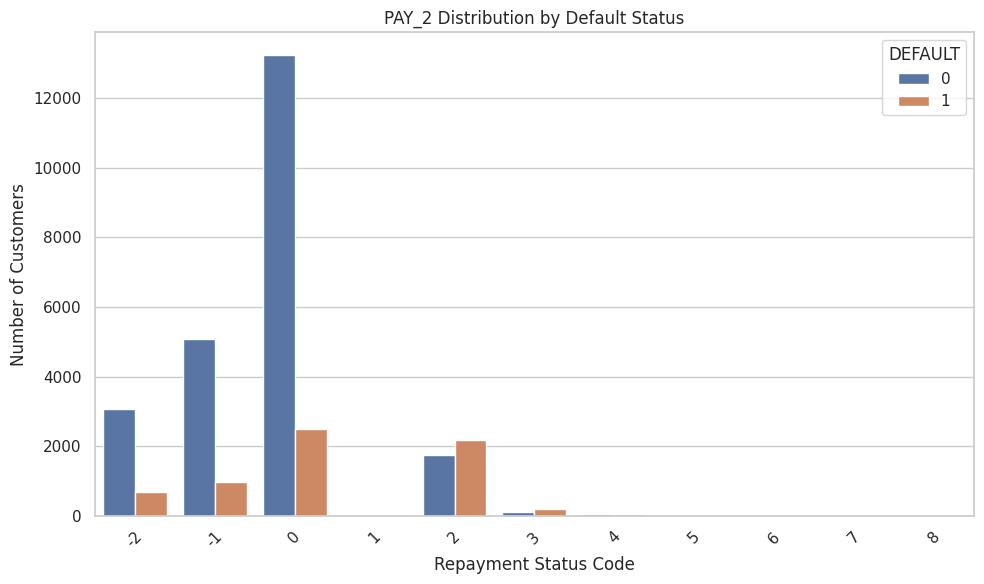

Figure saved successfully: /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/figures/pay_3_by_default.png


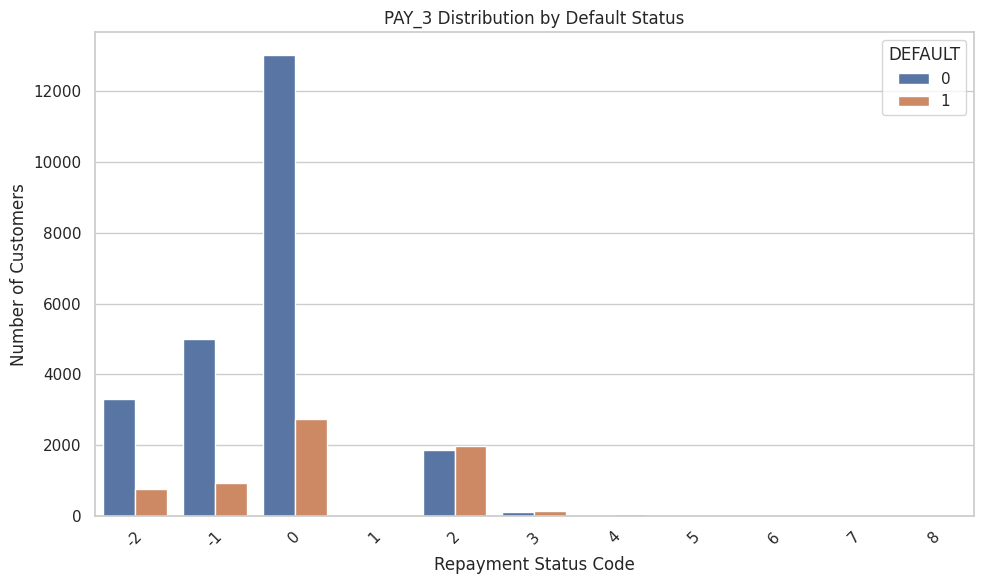

Figure saved successfully: /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/figures/pay_4_by_default.png


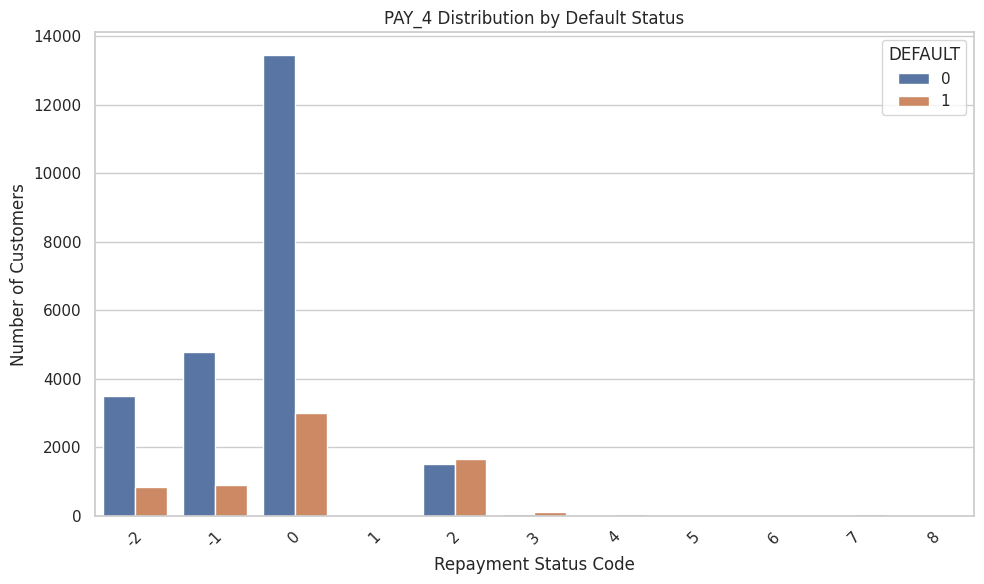

Figure saved successfully: /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/figures/pay_5_by_default.png


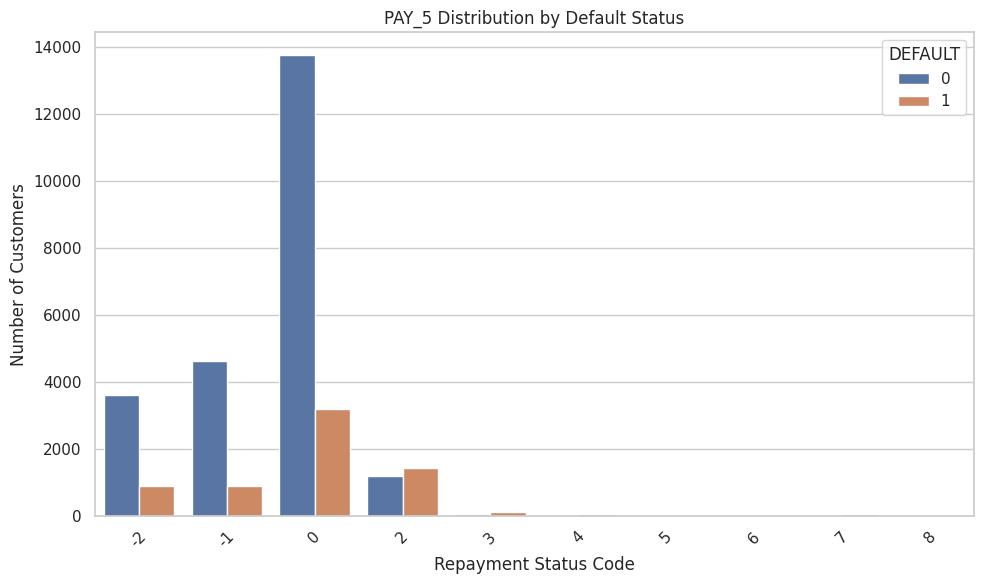

Figure saved successfully: /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/figures/pay_6_by_default.png


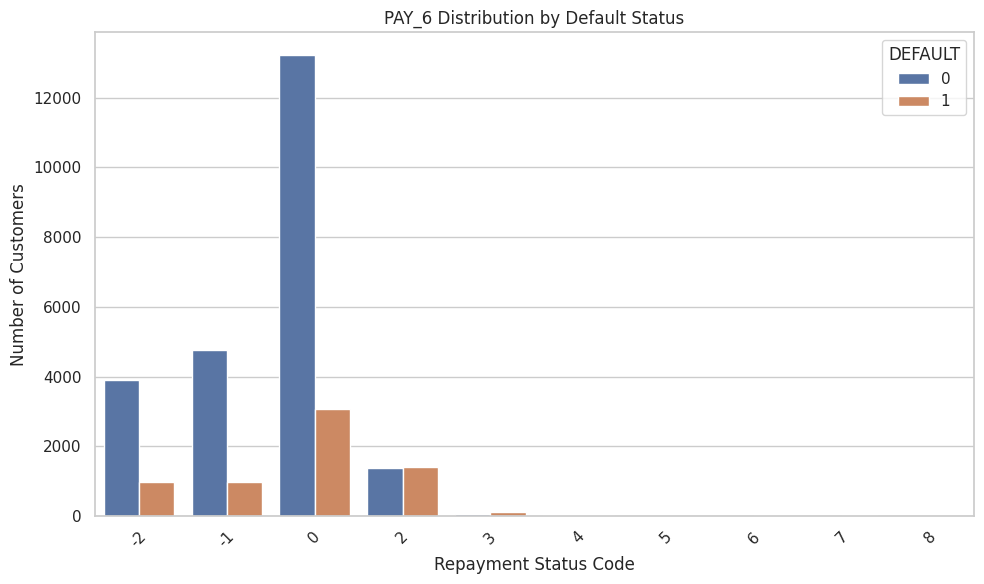

In [34]:
# ============================================================
# REPAYMENT STATUS DISTRIBUTIONS
# ============================================================

# Create a separate graph for each repayment status feature.
for feature in repayment_features:

    # Create a figure.
    plt.figure(figsize=(10, 6))

    # Create a count plot.
    sns.countplot(
        data=df,
        x=feature,
        hue="DEFAULT"
    )

    # Add title.
    plt.title(
        f"{feature} Distribution by Default Status"
    )

    # Add labels.
    plt.xlabel("Repayment Status Code")
    plt.ylabel("Number of Customers")

    # Rotate labels if necessary.
    plt.xticks(rotation=45)

    # Adjust spacing.
    plt.tight_layout()

    # Save the figure.
    save_figure(
        f"{feature.lower()}_by_default.png"
    )

    # Display the figure.
    plt.show()

Figure saved successfully: /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/figures/10_average_repayment_status_by_default.png


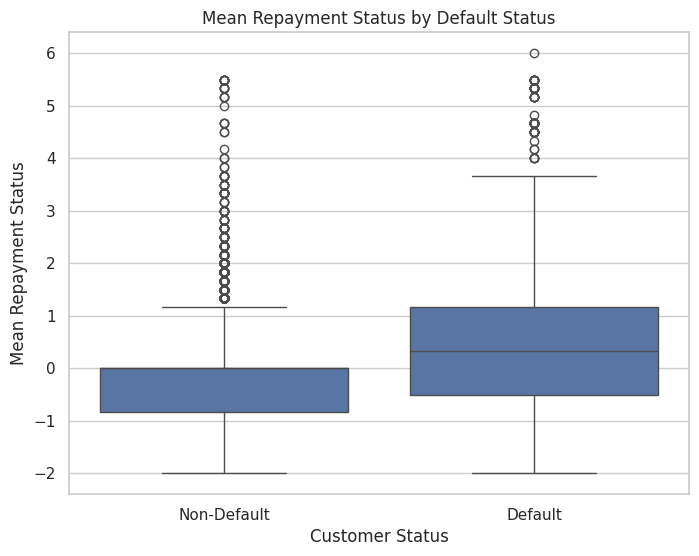

In [36]:
# ============================================================
# Mean REPAYMENT STATUS BY DEFAULT
# ============================================================

# Calculate the average repayment status for each customer.
# Higher values generally indicate greater repayment delay.
df["TEMP_AVG_PAY_STATUS"] = df[repayment_features].mean(axis=1)

# Compare average repayment behaviour between the two classes.
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="DEFAULT",
    y="TEMP_AVG_PAY_STATUS"
)

# Make labels readable.
plt.xticks(
    ticks=[0, 1],
    labels=["Non-Default", "Default"]
)

# Add title.
plt.title("Mean Repayment Status by Default Status")

# Add labels.
plt.xlabel("Customer Status")
plt.ylabel("Mean Repayment Status")

# Save the figure.
save_figure("10_average_repayment_status_by_default.png")

# Display the figure.
plt.show()

# Remove the temporary exploratory column.
# This feature will be created properly in Notebook 2.
df = df.drop(columns=["TEMP_AVG_PAY_STATUS"])

Figure saved successfully: /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/figures/bill_amt1_distribution.png


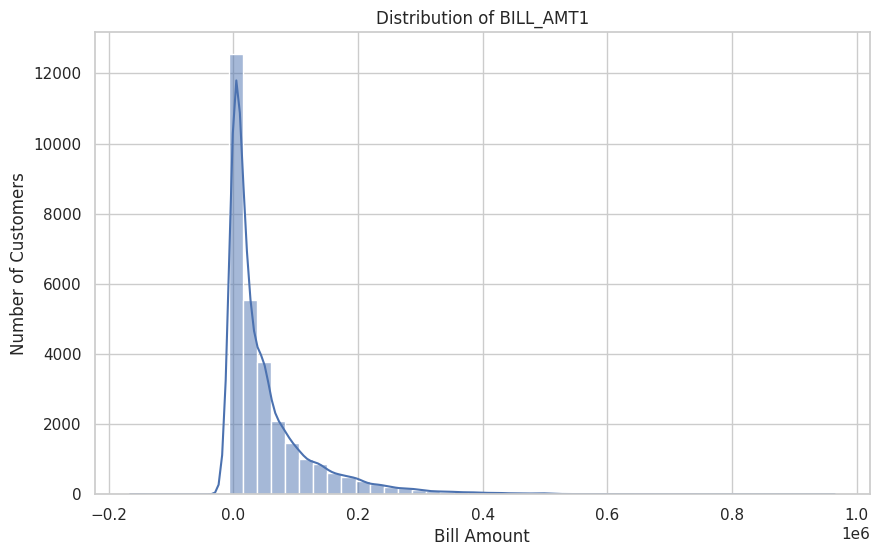

Figure saved successfully: /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/figures/bill_amt2_distribution.png


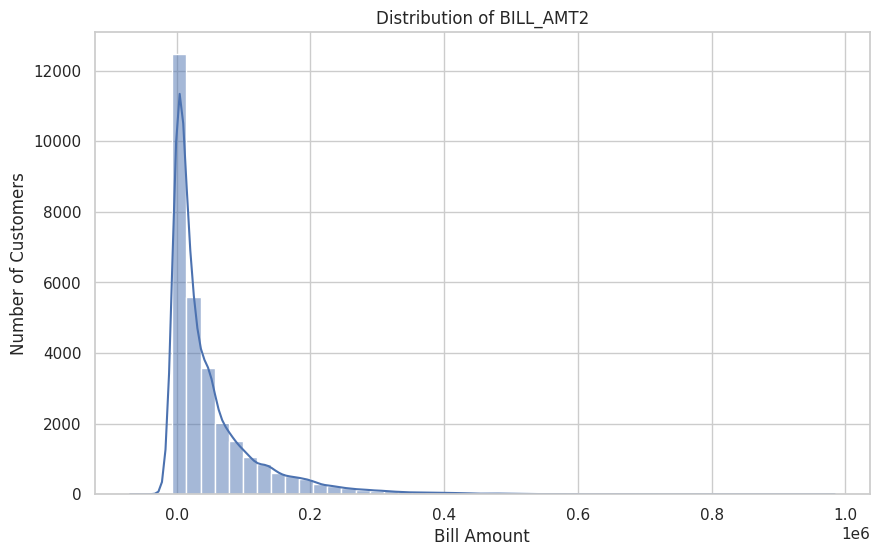

Figure saved successfully: /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/figures/bill_amt3_distribution.png


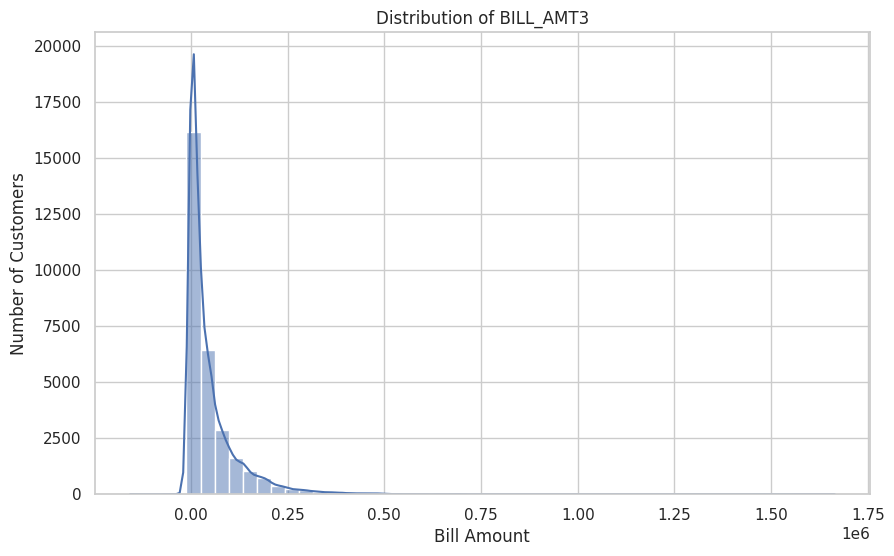

Figure saved successfully: /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/figures/bill_amt4_distribution.png


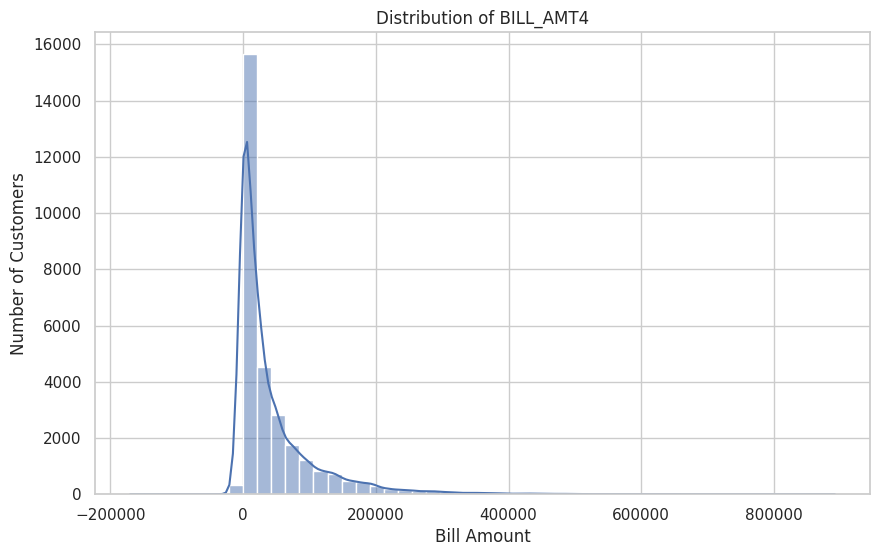

Figure saved successfully: /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/figures/bill_amt5_distribution.png


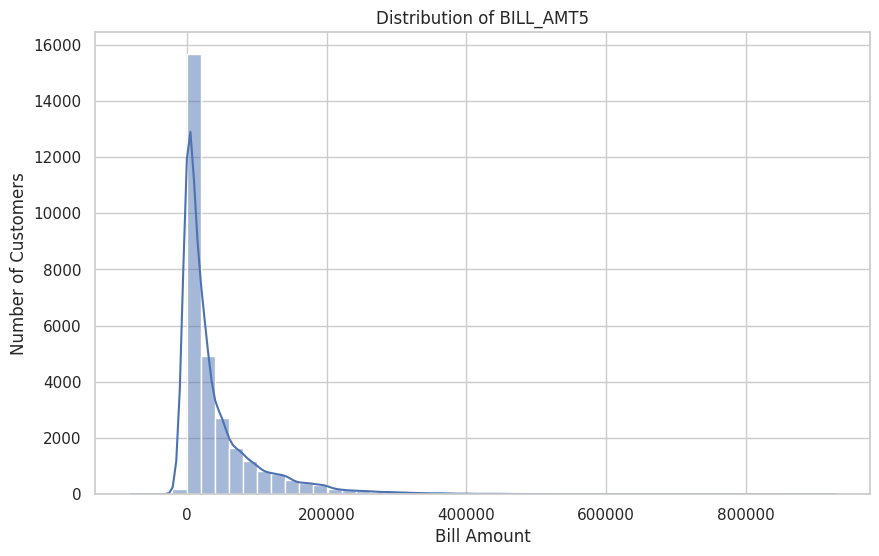

Figure saved successfully: /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/figures/bill_amt6_distribution.png


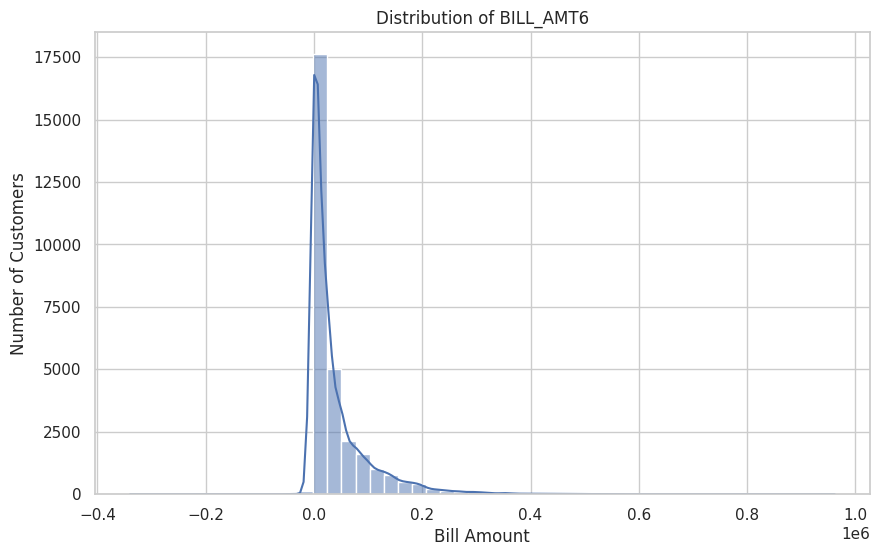

In [37]:
# ============================================================
# BILL AMOUNT DISTRIBUTIONS
# ============================================================

# Create one graph for each monthly bill amount.
for feature in bill_features:

    # Create a figure.
    plt.figure(figsize=(10, 6))

    # Use a histogram to visualize the distribution.
    sns.histplot(
        data=df,
        x=feature,
        bins=50,
        kde=True
    )

    # Add title.
    plt.title(
        f"Distribution of {feature}"
    )

    # Add labels.
    plt.xlabel("Bill Amount")
    plt.ylabel("Number of Customers")

    # Save the figure.
    save_figure(
        f"{feature.lower()}_distribution.png"
    )

    # Display the graph.
    plt.show()

Figure saved successfully: /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/figures/pay_amt1_distribution.png


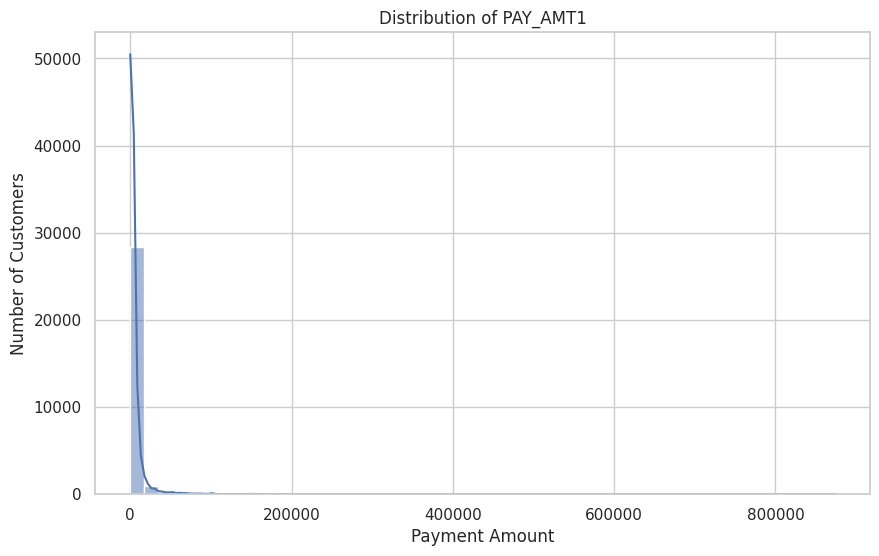

Figure saved successfully: /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/figures/pay_amt2_distribution.png


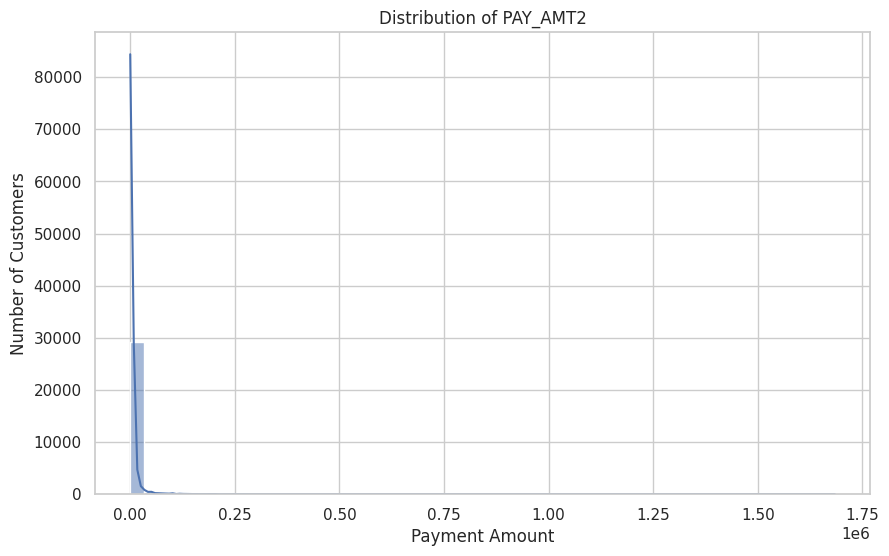

Figure saved successfully: /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/figures/pay_amt3_distribution.png


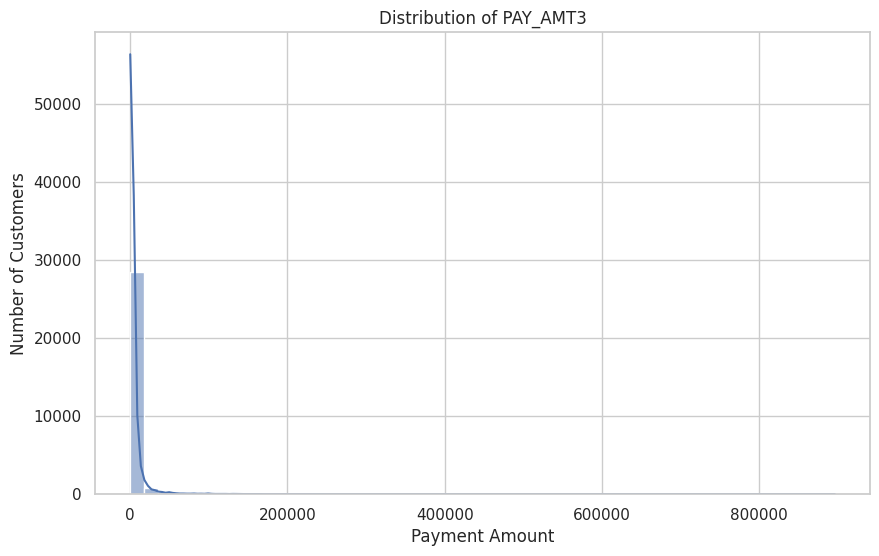

Figure saved successfully: /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/figures/pay_amt4_distribution.png


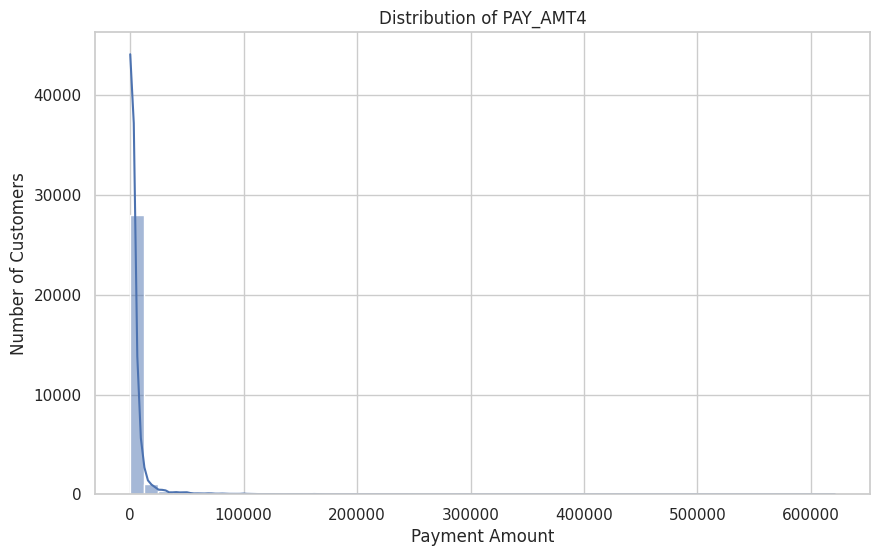

Figure saved successfully: /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/figures/pay_amt5_distribution.png


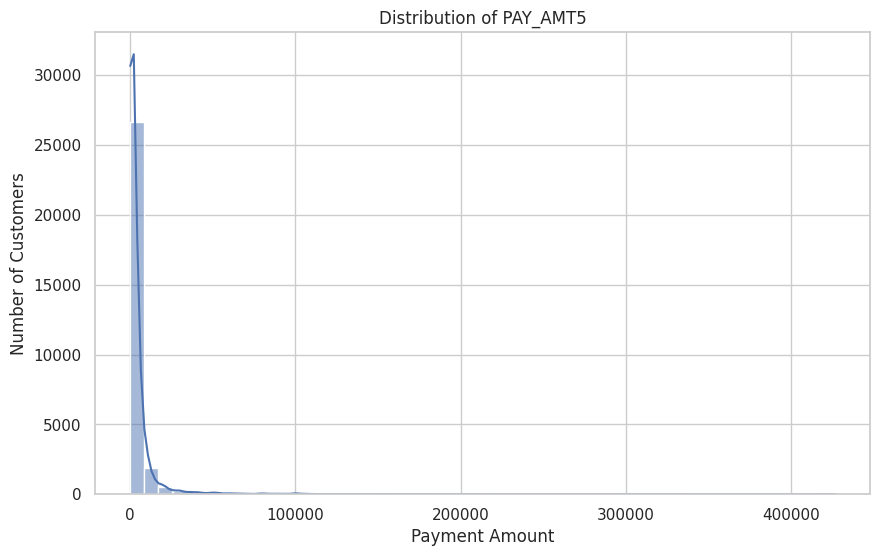

Figure saved successfully: /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/figures/pay_amt6_distribution.png


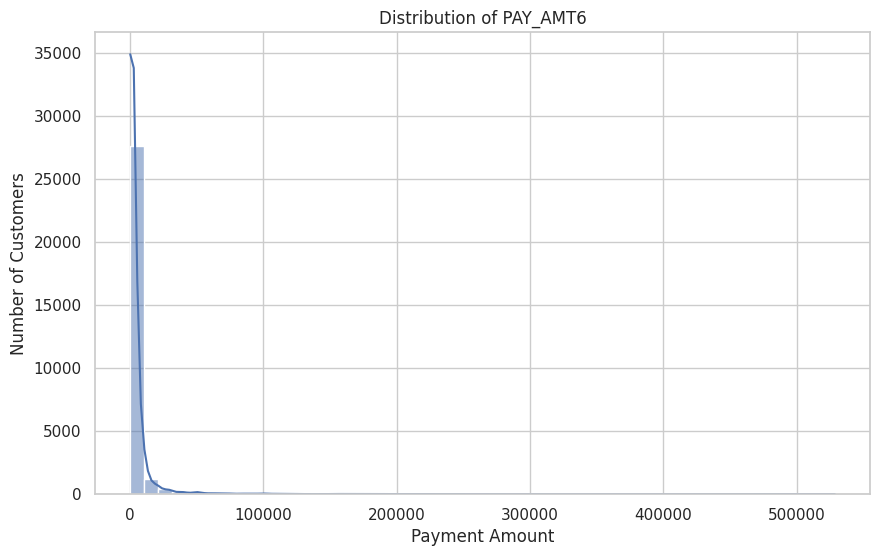

In [38]:
# ============================================================
# PAYMENT AMOUNT DISTRIBUTIONS
# ============================================================

# Create one graph for each monthly payment amount.
for feature in payment_features:

    # Create a figure.
    plt.figure(figsize=(10, 6))

    # Plot the distribution.
    sns.histplot(
        data=df,
        x=feature,
        bins=50,
        kde=True
    )

    # Add title.
    plt.title(
        f"Distribution of {feature}"
    )

    # Add labels.
    plt.xlabel("Payment Amount")
    plt.ylabel("Number of Customers")

    # Save the graph.
    save_figure(
        f"{feature.lower()}_distribution.png"
    )

    # Display the graph.
    plt.show()

Outlier Analysis

In [40]:
# ============================================================
# OUTLIER ANALYSIS USING THE IQR METHOD
# ============================================================

def calculate_iqr_outlier_summary(dataframe, columns):
    """
    Calculate the number and percentage of IQR-based outliers
    for selected numerical columns.

    The IQR method defines:
        Lower Bound = Q1 - 1.5 * IQR
        Upper Bound = Q3 + 1.5 * IQR
    """

    # Create an empty list to store results.
    results = []

    # Analyze each selected feature.
    for column in columns:

        # Calculate the first quartile.
        q1 = dataframe[column].quantile(0.25)

        # Calculate the third quartile.
        q3 = dataframe[column].quantile(0.75)

        # Calculate the interquartile range.
        iqr = q3 - q1

        # Calculate the lower boundary.
        lower_bound = q1 - 1.5 * iqr

        # Calculate the upper boundary.
        upper_bound = q3 + 1.5 * iqr

        # Identify outliers.
        outlier_mask = (
            (dataframe[column] < lower_bound) |
            (dataframe[column] > upper_bound)
        )

        # Count outliers.
        outlier_count = outlier_mask.sum()

        # Calculate percentage.
        outlier_percentage = (
            outlier_count / len(dataframe)
        ) * 100

        # Store the result.
        results.append({
            "Feature": column,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "Lower Bound": lower_bound,
            "Upper Bound": upper_bound,
            "Outlier Count": outlier_count,
            "Outlier Percentage": outlier_percentage
        })

    # Convert results into a DataFrame.
    return pd.DataFrame(results)

In [41]:
# ============================================================
# RUN OUTLIER ANALYSIS
# ============================================================

# Combine bill and payment features.
financial_amount_features = (
    bill_features +
    payment_features
)

# Generate the outlier summary.
outlier_summary = calculate_iqr_outlier_summary(
    df,
    financial_amount_features
)

# Round values for readability.
outlier_summary = outlier_summary.round(2)

# Display the summary.
display(outlier_summary)

# Save the table to Google Drive.
outlier_summary.to_csv(
    os.path.join(
        TABLES_DIR,
        "outlier_analysis_summary.csv"
    ),
    index=False
)

print("Outlier analysis saved successfully.")

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,BILL_AMT1,3595.0,67260.0,63665.0,-91902.5,162757.5,2386,7.96
1,BILL_AMT2,3010.0,64109.0,61099.0,-88638.5,155757.5,2390,7.98
2,BILL_AMT3,2711.0,60201.0,57490.0,-83524.0,146436.0,2469,8.24
3,BILL_AMT4,2360.0,54601.0,52241.0,-76001.5,132962.5,2616,8.73
4,BILL_AMT5,1787.0,50247.0,48460.0,-70903.0,122937.0,2724,9.09
5,BILL_AMT6,1262.0,49252.0,47990.0,-70723.0,121237.0,2688,8.97
6,PAY_AMT1,1000.0,5008.0,4008.0,-5012.0,11020.0,2742,9.15
7,PAY_AMT2,850.0,5000.0,4150.0,-5375.0,11225.0,2723,9.09
8,PAY_AMT3,390.0,4512.0,4122.0,-5793.0,10695.0,2596,8.66
9,PAY_AMT4,300.0,4016.0,3716.0,-5274.0,9590.0,2993,9.99


Outlier analysis saved successfully.


CORRELATION ANALYSIS

Figure saved successfully: /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/figures/correlation_heatmap.png


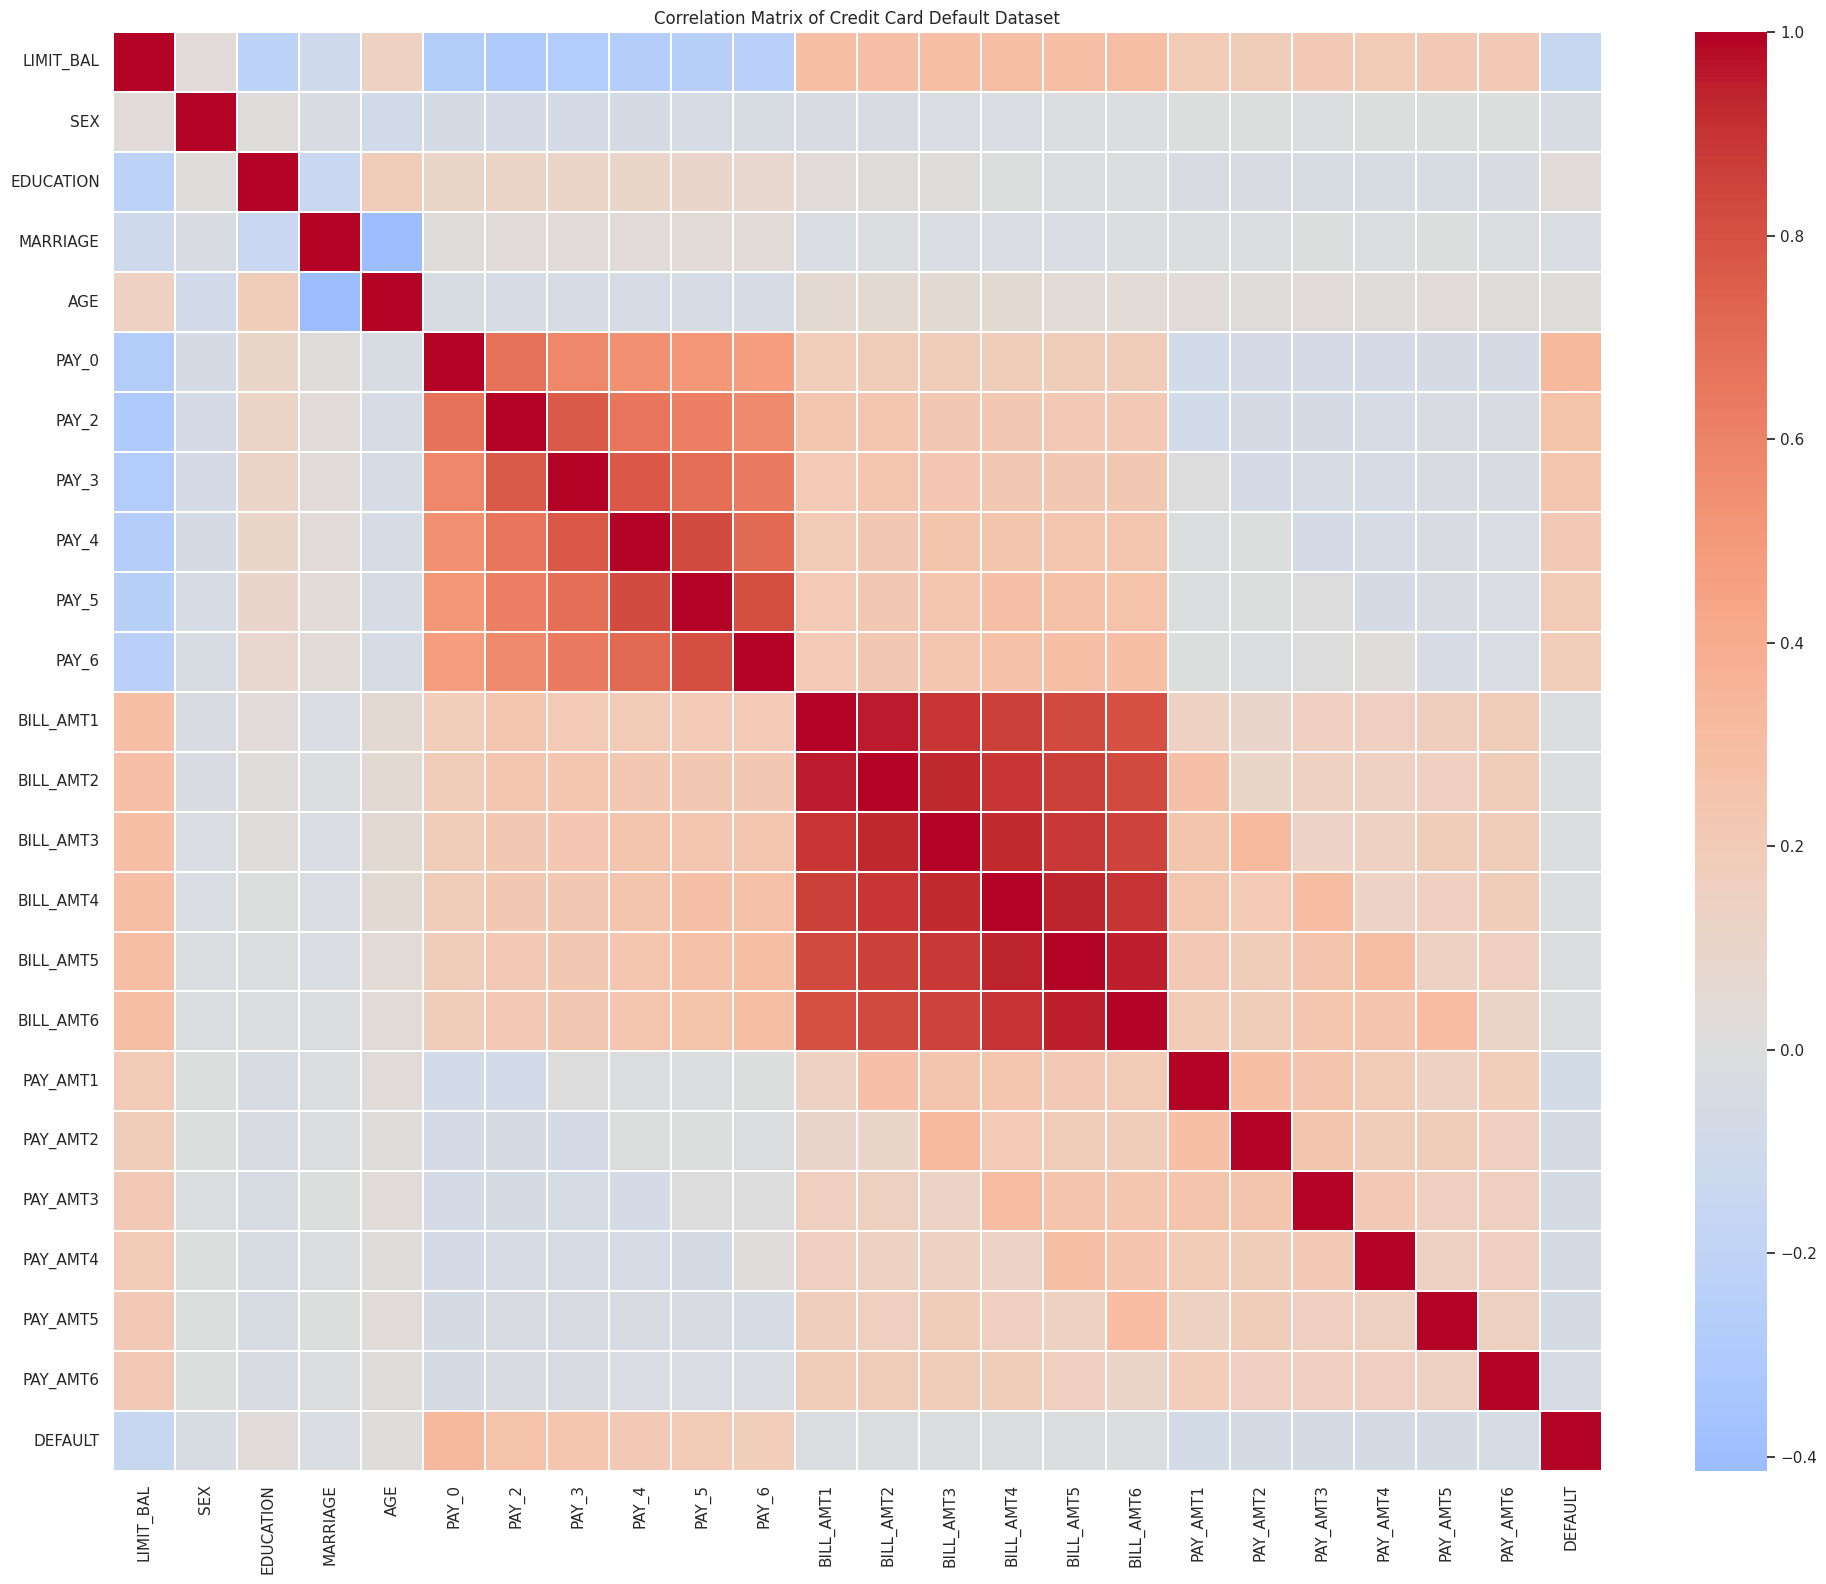

In [42]:
# Calculate Pearson correlation coefficients.
correlation_matrix = df.corr()

# Create a large figure.
plt.figure(figsize=(20, 16))

# Plot the correlation heatmap.
sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.2
)

# Add title.
plt.title(
    "Correlation Matrix of Credit Card Default Dataset"
)

# Adjust layout.
plt.tight_layout()

# Save the graph.
save_figure("correlation_heatmap.png")

# Display the graph.
plt.show()

FEATURE CORRELATION WITH TARGET

In [43]:
# Calculate correlation of every feature with DEFAULT.
target_correlations = (
    df.corr()["DEFAULT"]
    .drop("DEFAULT")
    .sort_values()
)

# Display the correlations.
display(
    target_correlations.to_frame(
        name="Correlation with DEFAULT"
    )
)

,Correlation with DEFAULT
LIMIT_BAL,-0.153871
PAY_AMT1,-0.073015
PAY_AMT2,-0.058643
PAY_AMT4,-0.056898
PAY_AMT3,-0.056319
PAY_AMT5,-0.055194
PAY_AMT6,-0.053250
SEX,-0.039742
MARRIAGE,-0.024019
BILL_AMT1,-0.019758


TOP FEATURE-TARGET CORRELATIONS

Figure saved successfully: /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/figures/top_feature_target_correlations.png


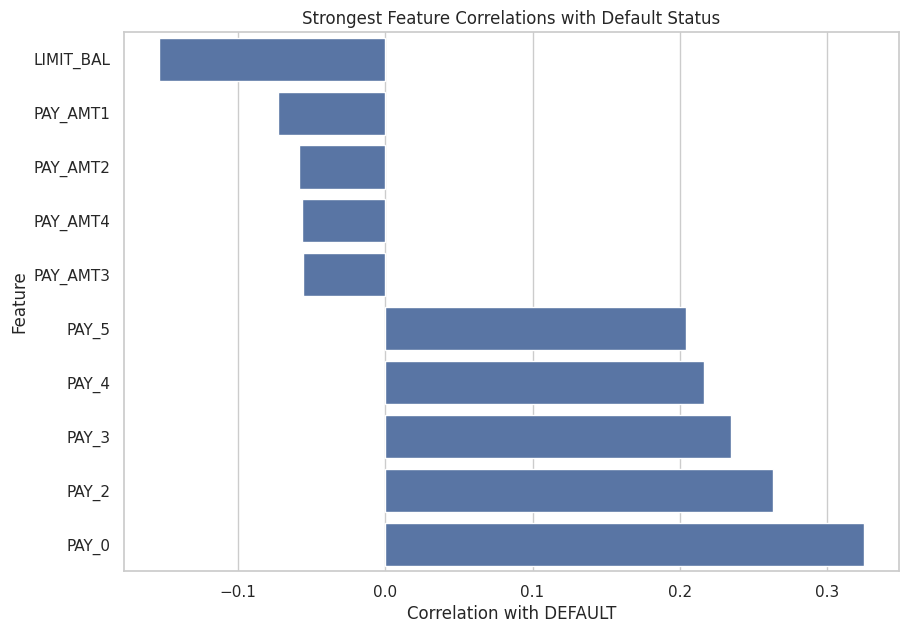

In [44]:
# Select the 10 strongest positive and negative correlations.
top_negative = target_correlations.head(5)
top_positive = target_correlations.tail(5)

# Combine both groups.
top_correlations = pd.concat([
    top_negative,
    top_positive
])

# Sort values for plotting.
top_correlations = top_correlations.sort_values()

# Create the plot.
plt.figure(figsize=(10, 7))

sns.barplot(
    x=top_correlations.values,
    y=top_correlations.index
)

# Add title.
plt.title(
    "Strongest Feature Correlations with Default Status"
)

# Add labels.
plt.xlabel("Correlation with DEFAULT")
plt.ylabel("Feature")

# Save the figure.
save_figure("top_feature_target_correlations.png")

# Display the figure.
plt.show()

Saving Clean Dataset

In [45]:
# Check for missing values one final time.
print("Total missing values:")
print(df.isnull().sum().sum())

# Check for duplicate rows.
print("\nTotal duplicate rows:")
print(df.duplicated().sum())

# Check the final shape.
print("\nFinal dataset shape:")
print(df.shape)

# Check target distribution.
print("\nTarget distribution:")
print(df["DEFAULT"].value_counts())

Total missing values:
0

Total duplicate rows:
0

Final dataset shape:
(29965, 24)

Target distribution:
DEFAULT
0    23335
1     6630
Name: count, dtype: int64


SAVE CLEAN DATASET TO GOOGLE DRIVE

In [46]:
# Define the final path for the cleaned dataset.
CLEAN_DATA_PATH = os.path.join(
    PROCESSED_DATA_DIR,
    "credit_card_default_clean.csv"
)

# Save the cleaned DataFrame.
df.to_csv(
    CLEAN_DATA_PATH,
    index=False
)

# Verify that the file exists.
if os.path.exists(CLEAN_DATA_PATH):

    print("Clean dataset saved successfully!")
    print(f"Location: {CLEAN_DATA_PATH}")

else:

    print("Error: Clean dataset was not saved.")

Clean dataset saved successfully!
Location: /content/drive/MyDrive/Colab Notebooks/Internship Work/data/processed/credit_card_default_clean.csv


CREATE A DATA DICTIONARY

In [47]:
#  Create a dictionary containing feature descriptions.
data_dictionary = {

    "LIMIT_BAL":
        "Amount of given credit in NT dollars.",

    "SEX":
        "Gender of the customer.",

    "EDUCATION":
        "Education level category.",

    "MARRIAGE":
        "Marital status category.",

    "AGE":
        "Age of the customer in years.",

    "PAY_0":
        "Repayment status in the most recent month.",

    "PAY_2":
        "Repayment status two months before the target month.",

    "PAY_3":
        "Repayment status three months before the target month.",

    "PAY_4":
        "Repayment status four months before the target month.",

    "PAY_5":
        "Repayment status five months before the target month.",

    "PAY_6":
        "Repayment status six months before the target month.",

    "DEFAULT":
        "Whether the customer defaulted on the credit card payment in the following month."
}

# Convert the dictionary into a DataFrame.
data_dictionary_df = pd.DataFrame(
    list(data_dictionary.items()),
    columns=[
        "Feature",
        "Description"
    ]
)

# Save the data dictionary.
data_dictionary_df.to_csv(
    os.path.join(
        TABLES_DIR,
        "data_dictionary.csv"
    ),
    index=False
)

# Display the data dictionary.
display(data_dictionary_df)

,Feature,Description
0,LIMIT_BAL,Amount of given credit in NT dollars.
1,SEX,Gender of the customer.
2,EDUCATION,Education level category.
3,MARRIAGE,Marital status category.
4,AGE,Age of the customer in years.
5,PAY_0,Repayment status in the most recent month.
6,PAY_2,Repayment status two months before the target ...
7,PAY_3,Repayment status three months before the targe...
8,PAY_4,Repayment status four months before the target...
9,PAY_5,Repayment status five months before the target...


In [48]:
print("=" * 60)
print("RAW DATA ANALYSIS NOTEBOOK COMPLETED")
print("=" * 60)

print(f"Final dataset shape: {df.shape}")
print(f"Total records: {len(df):,}")
print(f"Total predictors: {df.shape[1] - 1}")
print(f"Target variable: DEFAULT")

print("\nTarget Distribution:")
print(
    df["DEFAULT"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename({
        0: "Non-Default (%)",
        1: "Default (%)"
    })
)

print("\nSaved Files:")
print(f"Clean dataset: {CLEAN_DATA_PATH}")
print(f"Figures directory: {FIGURES_DIR}")
print(f"Tables directory: {TABLES_DIR}")

print("\nNotebook 1 completed successfully.")

RAW DATA ANALYSIS NOTEBOOK COMPLETED
Final dataset shape: (29965, 24)
Total records: 29,965
Total predictors: 23
Target variable: DEFAULT

Target Distribution:
DEFAULT
Non-Default (%)    77.87
Default (%)        22.13
Name: proportion, dtype: float64

Saved Files:
Clean dataset: /content/drive/MyDrive/Colab Notebooks/Internship Work/data/processed/credit_card_default_clean.csv
Figures directory: /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/figures
Tables directory: /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/tables

Notebook 1 completed successfully.
